In [2]:
from uszipcode import SearchEngine
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
from scipy.stats import mstats, pearsonr
warnings.filterwarnings('ignore')

In [3]:
avg_miles_by_state = pd.read_excel('Data/Avg_Miles_data_dictionary.xlsx')

avg_miles_by_state.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   STATE             51 non-null     object
 1   State Abbv        51 non-null     object
 2   Miles Per Driver  51 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


In [4]:
vehicles = pd.read_csv('Data/vehicles.csv')


In [5]:
vehicles.isna().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

In [6]:
vehicles.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [7]:
vehicles.state.nunique()

51

#### 12000 Miles per year is an average rating for a car.

#### Number of rows in vehicles data set that are with title status missing, salvage, part only are

In [8]:
vehicles[(vehicles['title_status'].isin(['missing','salvage','parts only']))  ].shape

(4880, 26)

### Data Filtering 
Include columns: 
1. Price
2. VIN
3. Posting Date
4. Year
5. Manufacturer
6. Model
7. Cylinders
8. Drive
9. Transmission
10. Description
11. State

### Vehicles Datset


In [9]:
VC = vehicles.copy()

In [10]:
VC.title_status.unique()

array([nan, 'clean', 'rebuilt', 'lien', 'salvage', 'missing',
       'parts only'], dtype=object)

In [11]:
print('Shape of vehicles dataset before filtering: ',VC.shape)

# Create a boolean mask to identify rows where 'salvage' is True and 'condition' is 'poor'
mask = ((VC['title_status'].isin(['clean', 'rebuilt'])) | (VC['title_status'].isna()))

VC_filtered = VC[mask]
print('Shape of vehicles dataset with filter on salvage: ',VC_filtered.shape)

Shape of vehicles dataset before filtering:  (426880, 26)
Shape of vehicles dataset with filter on salvage:  (420578, 26)


In [12]:
# define numerical & categorical columns
numeric_features = [feature for feature in VC_filtered.columns if VC_filtered[feature].dtype != 'O']
categorical_features = [feature for feature in VC_filtered.columns if VC_filtered[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 7 numerical features : ['id', 'price', 'year', 'odometer', 'county', 'lat', 'long']

We have 19 categorical features : ['url', 'region', 'region_url', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'state', 'posting_date']


In [13]:
selected_columns_VC = ['price','region','VIN', 'posting_date','year', 'manufacturer', 'model', 'cylinders','drive','transmission', 'odometer','description','state']

VC_df = VC_filtered[selected_columns_VC].copy()

In [14]:
print(VC_df.shape)
VC_df.isna().sum()

(420578, 13)


price                0
region               0
VIN             155951
posting_date        68
year              1205
manufacturer     17191
model             5075
cylinders       175946
drive           128629
transmission      2555
odometer          4396
description         70
state                0
dtype: int64

### Used Cars Dataset

In [ ]:
# Code to showcase how UC_filtered is formed!
# Not needed to run this block as we are using UC_filtered dataset which will be loaded later in the script!
used_cars_data = pd.read_csv('Data/used_cars_data.csv') 
used_cars_data.columns

UC = used_cars_data.copy()
print('Shape of used cars dataset before filtering: ',UC.shape)

# Create a boolean mask to identify rows where 'salvage' is True and 'condition' is 'poor'
mask = ((UC['salvage'] == False) & 
        (UC['frame_damaged'] == False) &
        (UC['latitude'].notna()) &     # Check for non-null values in 'lat' column
    (UC['latitude'] != '') &       # Check for non-empty values in 'lat' column
    (UC['longitude'].notna()) &    # Check for non-null values in 'long' column
    (UC['longitude'] != '') &      # Check for non-empty values in 'long' column
    (UC['dealer_zip'].notna()) &  # Check for non-null values in 'dealer_zip' column
    (UC['dealer_zip'] != ''))

# Drop rows where both conditions are met
UC_filtered = UC[mask]

print('Shape of used cars dataset with filter on salvage: ',UC_filtered.shape)

In [17]:
used_cars_data = pd.read_csv('Data/mega_df.csv') 
used_cars_data.columns

In [ ]:
UC = used_cars_data.copy()
print('Shape of used cars dataset before filtering: ',UC.shape)

In [ ]:
# Create a boolean mask to identify rows where 'salvage' is True and 'condition' is 'poor'
mask = ((UC['salvage'] == False) & 
        (UC['frame_damaged'] == False) &
        (UC['latitude'].notna()) &     # Check for non-null values in 'lat' column
    (UC['latitude'] != '') &       # Check for non-empty values in 'lat' column
    (UC['longitude'].notna()) &    # Check for non-null values in 'long' column
    (UC['longitude'] != '') &      # Check for non-empty values in 'long' column
    (UC['dealer_zip'].notna()) &  # Check for non-null values in 'dealer_zip' column
    (UC['dealer_zip'] != ''))

# Drop rows where both conditions are met
UC_filtered = UC[mask]

print('Shape of used cars dataset with filter on salvage: ',UC_filtered.shape)

In [15]:
UC_filtered = pd.read_csv('UC_filtered.csv')

MemoryError: Unable to allocate 64.0 KiB for an array with shape (8192,) and data type int64

In [41]:
UC_filtered.head()

,Unnamed: 0,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,...,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year,state
0,2,JF1VA2M67G9829723,35.4 in,NaN,NaN,NaN,Sedan,NaN,Guaynabo,17.0,...,6-Speed Manual,t58994,Base,NaN,AWD,All-Wheel Drive,104.3 in,78.9 in,2016,PR
1,5,SALYK2EX1LA261711,37.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,...,8-Speed Automatic Overdrive,t85614,P250 R-Dynamic S AWD,NaN,AWD,All-Wheel Drive,113.1 in,84.4 in,2020,PR
2,9,SALZL2GX4LH007593,33.8 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,...,9-Speed Automatic Overdrive,t85531,P300 R-Dynamic SE AWD,NaN,AWD,All-Wheel Drive,105.6 in,82.7 in,2020,PR
3,10,ZARBAAC41FM129303,--,NaN,NaN,NaN,Coupe,NaN,Guaynabo,NaN,...,6-Speed Automatic,t56834,Launch Edition Coupe RWD,NaN,RWD,Rear-Wheel Drive,93.7 in,73.5 in,2015,PR
4,12,WBA8B7C53GK368522,35.1 in,NaN,NaN,NaN,Sedan,NaN,Guaynabo,22.0,...,8-Speed Automatic,t58802,340i xDrive Sedan AWD,NaN,AWD,All-Wheel Drive,110.6 in,80 in,2016,PR


In [42]:
len(UC_filtered)

1548119

In [43]:
UC_filtered.state.isna().sum()

1312

In [44]:
# define numerical & categorical columns
numeric_features = [feature for feature in UC_filtered.columns if UC_filtered[feature].dtype != 'O']
categorical_features = [feature for feature in UC_filtered.columns if UC_filtered[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 27 numerical features : ['Unnamed: 0', 'city_fuel_economy', 'combine_fuel_economy', 'daysonmarket', 'engine_displacement', 'fleet', 'frame_damaged', 'franchise_dealer', 'has_accidents', 'highway_fuel_economy', 'horsepower', 'isCab', 'is_certified', 'is_new', 'latitude', 'listing_id', 'longitude', 'mileage', 'owner_count', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'theft_title', 'vehicle_damage_category', 'year']

We have 41 categorical features : ['vin', 'back_legroom', 'bed', 'bed_height', 'bed_length', 'body_type', 'cabin', 'city', 'dealer_zip', 'description', 'engine_cylinders', 'engine_type', 'exterior_color', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'height', 'interior_color', 'is_cpo', 'is_oemcpo', 'length', 'listed_date', 'listing_color', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'model_name', 'power', 'sp_name', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'wheel_syst

In [45]:
avg_miles_by_state.head()

,STATE,State Abbv,Miles Per Driver
0,Alabama,AL,19589
1,Alaska,AK,11077
2,Arizona,AZ,12728
3,Arkansas,AR,16657
4,California,CA,11464


In [46]:
avg_miles_by_state.columns

Index(['STATE', 'State Abbv', 'Miles Per Driver'], dtype='object')

In [47]:
# Merge the two dataframes on the 'state' column
merged_UC_filtered = pd.merge(UC_filtered, avg_miles_by_state, left_on='state', right_on='STATE', how='left')

In [48]:
# Merge the two dataframes on the 'state' column
merged_UC_filtered = pd.merge(UC_filtered, avg_miles_by_state, left_on='state', right_on='STATE', how='left')

# Convert 'manufacturing_year' column to integer type
merged_UC_filtered['year'] = merged_UC_filtered['year'].astype(int)

# Calculate odometer based on age and avg_miles_per_year
merged_UC_filtered['odometer'] = (2024 - merged_UC_filtered['year']) * merged_UC_filtered['Miles Per Driver']

# Drop redundant columns
merged_UC_filtered.drop(['STATE', 'Miles Per Driver'], axis=1, inplace=True)



In [22]:
merged_UC_filtered.columns

Index(['Unnamed: 0', 'vin', 'back_legroom', 'bed', 'bed_height', 'bed_length',
       'body_type', 'cabin', 'city', 'city_fuel_economy',
       'combine_fuel_economy', 'daysonmarket', 'dealer_zip', 'description',
       'engine_cylinders', 'engine_displacement', 'engine_type',
       'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer',
       'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type',
       'has_accidents', 'height', 'highway_fuel_economy', 'horsepower',
       'interior_color', 'isCab', 'is_certified', 'is_cpo', 'is_new',
       'is_oemcpo', 'latitude', 'length', 'listed_date', 'listing_color',
       'listing_id', 'longitude', 'main_picture_url', 'major_options',
       'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count',
       'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id',
       'sp_name', 'theft_title', 'torque', 'transmission',
       'transmission_display', 'trimId', 'trim_name',
       'vehicle_d

In [23]:

selected_columns_UC = ['price','city','vin', 'listed_date','year', 'make_name', 'model_name', 'engine_cylinders','wheel_system','transmission','odometer', 'description','state']

UC_df = merged_UC_filtered[selected_columns_UC].copy()


In [50]:
print(merged_UC_filtered.shape)
merged_UC_filtered.isna().sum()

(1548119, 70)


Unnamed: 0            0
vin                   0
back_legroom      65591
bed             1530772
bed_height      1351552
                 ...   
width             65591
year                  0
state              1312
State Abbv      1548119
odometer        1548119
Length: 70, dtype: int64

#### Rename columns matching Standard format in SSMS for Used_Cars_DF table in test_UCPP database

In [25]:
VC_df.columns

Index(['price', 'region', 'VIN', 'posting_date', 'year', 'manufacturer',
       'model', 'cylinders', 'drive', 'transmission', 'odometer',
       'description', 'state'],
      dtype='object')

In [26]:
VC_df.rename(columns = {'price':'Price','region':'City','vin':'VIN', 'posting_date':'Date', 'manufacturer':'Manufacturer', 'model':'Model Name', 'description':'Post Content', 'year':'Manufacturing Year', 'state':'State'}, inplace=True)
VC_df.columns

Index(['Price', 'City', 'VIN', 'Date', 'Manufacturing Year', 'Manufacturer',
       'Model Name', 'cylinders', 'drive', 'transmission', 'odometer',
       'Post Content', 'State'],
      dtype='object')

In [27]:
UC_df.columns

Index(['price', 'city', 'vin', 'listed_date', 'year', 'make_name',
       'model_name', 'engine_cylinders', 'wheel_system', 'transmission',
       'odometer', 'description', 'state'],
      dtype='object')

In [28]:
UC_df.rename(columns = {'price':'Price','city':'City','vin':'VIN', 'listed_date':'Date', 'make_name':'Manufacturer', 'model_name':'Model Name', 'engine_cylinders':'cylinders','wheel_system':'drive', 'description':'Post Content', 'year':'Manufacturing Year', 'state':'State'}, inplace=True)
UC_df.columns

Index(['Price', 'City', 'VIN', 'Date', 'Manufacturing Year', 'Manufacturer',
       'Model Name', 'cylinders', 'drive', 'transmission', 'odometer',
       'Post Content', 'State'],
      dtype='object')

In [29]:
df = pd.concat([VC_df, UC_df], axis=0)
print(df.shape)

(1968697, 13)


In [30]:
df.head()

,Price,City,VIN,Date,Manufacturing Year,Manufacturer,Model Name,cylinders,drive,transmission,odometer,Post Content,State
0,6000.0,prescott,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,11900.0,fayetteville,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,21000.0,florida keys,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,1500.0,worcester / central MA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,4900.0,greensboro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [31]:
# define numerical & categorical columns
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

# print columns
print('We have {} numerical features : {}'.format(len(numeric_features), numeric_features))
print('\nWe have {} categorical features : {}'.format(len(categorical_features), categorical_features))

We have 3 numerical features : ['Price', 'Manufacturing Year', 'odometer']

We have 10 categorical features : ['City', 'VIN', 'Date', 'Manufacturer', 'Model Name', 'cylinders', 'drive', 'transmission', 'Post Content', 'State']


In [32]:
# Check for duplicates based on the 'VIN' column only
vin_duplicates = df[df.duplicated(subset=['VIN'], keep=False)]

# Get the number of duplicates
num_vin_duplicates = len(vin_duplicates)

# Print the number of duplicates based on 'VIN' column
print("Number of duplicates based on VIN:", num_vin_duplicates)

Number of duplicates based on VIN: 348863


In [33]:
df.isna().sum()

Price                       0
City                        0
VIN                    155951
Date                       68
Manufacturing Year       1205
Manufacturer            17191
Model Name               5075
cylinders              215344
drive                  178803
transmission            29027
odometer              1552515
Post Content            29079
State                    1312
dtype: int64

In [35]:
# Identify duplicates based on 'VIN' and 'posting_date'
duplicates = df[df.duplicated(subset=['VIN'], keep=False)]


def most_frequent(col):
  # Filter non-null values
  filtered_col = col.dropna()
  # Return the mode (most frequent value)
  return filtered_col.mode().iloc[0] if not filtered_col.empty else None

# Group data by 'VIN' and aggregate missing values
aggregated_data = duplicates.groupby('VIN').agg({
  'Manufacturing Year': 'first',  # Fill 'year' with the first non-null value
  'Manufacturer': 'first',        # Fill 'manufacturer' with the first non-null value
  'Model Name': 'first',          # Fill 'model' with the first non-null value
  'cylinders': most_frequent,            # Fill 'cylinders' with the most frequent value
  'drive': most_frequent,                # Fill 'drive' with the most frequent value
  'transmission': most_frequent,          # Fill 'transmission' with the most frequent value
  'State': 'first'                # Fill 'state' with the first non-null value
})

# Fill missing values in the original DataFrame
df.update(aggregated_data, overwrite=False)


In [36]:
df.isna().sum()

Price                       0
City                        0
VIN                    155951
Date                       68
Manufacturing Year       1205
Manufacturer            17191
Model Name               5075
cylinders              215344
drive                  178803
transmission            29027
odometer              1552515
Post Content            29079
State                    1312
dtype: int64

In [37]:
# Assuming you have a DataFrame named 'df' with columns 'VIN' and 'posting_date'
# Replace 'df' with your actual DataFrame

# Convert the 'posting_date' column to datetime if it's not already in datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce', format='%Y-%m-%dT%H:%M:%S%z')

# Sort the DataFrame by 'VIN' and 'posting_date' in descending order
df.sort_values(by=['VIN', 'Date'], ascending=[True, False], inplace=True)

# Drop duplicates based on 'VIN' and keep only the first (latest) record
df.drop_duplicates(subset='VIN', keep='first', inplace=True)

# Reset the index if needed
df.reset_index(drop=True, inplace=True)


In [38]:
# Check for duplicates based on the 'VIN' column only
vin_duplicates = df[df.duplicated(subset=['VIN'], keep=False)]

# Get the number of duplicates
num_vin_duplicates = len(vin_duplicates)

# Print the number of duplicates based on 'VIN' column
print("Number of duplicates based on VIN:", num_vin_duplicates)

Number of duplicates based on VIN: 0


#### Not using the below convention to drop duplicates based on two columns VIN and posting date

In [ ]:
# Check for duplicates based on both 'VIN' and 'posting_date' columns
multi_column_duplicates = df[df.duplicated(subset=['VIN', 'posting_date'], keep=False)]

# Get the number of duplicates
num_multi_column_duplicates = len(multi_column_duplicates)

# Print the number of duplicates based on both 'VIN' and 'posting_date' columns
print("Number of duplicates based on VIN and posting_date:", num_multi_column_duplicates)

In [79]:
df = pd.read_csv('C:/My Files/KG PC Backup/Personal Projects/UCPP/Notebooks/Data/mega_df.csv')

In [80]:
df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1544637
Manufacturing Year        593
Manufacturer             3036
Model Name                703
cylinders               87210
drive                   77274
transmission            27670
odometer              1546232
Post Content            28935
State                    1304
dtype: int64

In [81]:
new_df = df.copy()

In [82]:
new_df['Manufacturing Year'].unique()

array([1960., 1966., 1900., 2019.,   nan, 2017., 2012., 2013., 1997.,
       2020., 2018., 2014., 2016., 2015., 2011., 1937., 1967., 1925.,
       1926., 1924., 1968., 1940., 1947., 1938., 1949., 1955., 1952.,
       1935., 1948., 1962., 1930., 1929., 1928., 1931., 1974., 1965.,
       1969., 1957., 1972., 1995., 1950., 1939., 1953., 1979., 1978.,
       1927., 1961., 1959., 1954., 1923., 1951., 2003., 1963., 1964.,
       1956., 1958., 1976., 1970., 1971., 1973., 1980., 1989., 1991.,
       1933., 1946., 1981., 1983., 1977., 1994., 1992., 1993., 1988.,
       1975., 1996., 1984., 1999., 2007., 2000., 2009., 2010., 1987.,
       1936., 2005., 1941., 2002., 1934., 2006., 2001., 1998., 1985.,
       1932., 1942., 1915., 2004., 2008., 2021., 1982., 1986., 1990.,
       2022., 1905., 1903., 1921.])

In [83]:
print('Number of rows in dataset with car listings from 2000 Models: ', new_df[new_df['Manufacturing Year'] >= 2000].shape[0])
print('Number of rows in dataset with car listings from 2005 Models: ', new_df[new_df['Manufacturing Year'] >= 2005].shape[0])
print('Number of rows in dataset with car listings from 2010 Models: ', new_df[new_df['Manufacturing Year'] >= 2010].shape[0])

Number of rows in dataset with car listings from 2000 Models:  1646484
Number of rows in dataset with car listings from 2005 Models:  1612160
Number of rows in dataset with car listings from 2010 Models:  1495941


In [84]:
print('Number of rows in dataset with car listings from 2010 Models: ', new_df[(new_df['Manufacturing Year'] >= 2000) & (new_df['Price'] != 0)].shape[0])

Number of rows in dataset with car listings from 2010 Models:  1633954


In [85]:
new_df = new_df[(new_df['Manufacturing Year'] >= 2000) & (new_df['Price'] != 0)]

In [86]:
new_df['Manufacturer'].unique()

array(['Chevrolet', nan, 'Honda', 'Plymouth', 'Toyota', 'Aston Martin',
       'Nissan', 'Volvo', 'Ford', 'Dodge', 'Chrysler', 'Subaru',
       'Hyundai', 'Mercedes-Benz', 'Mazda', 'HUMMER', 'AM General', 'RAM',
       'JEEP', 'Acura', 'SRT', 'GMC', 'MINI', 'harley-davidson', 'Buick',
       'Pontiac', 'Oldsmobile', 'Cadillac', 'Audi', 'Saturn', 'Isuzu',
       'Lincoln', 'Mercury', 'Volkswagen', 'Saleen', 'Mitsubishi',
       'Suzuki', 'Lexus', 'FIAT', 'Saab', 'Kia', 'BMW', 'Scion',
       'Infiniti', 'Alfa Romeo', 'Karma', 'VPG', 'Tesla',
       'Mobility Ventures', 'Ariel', 'Daewoo', 'Genesis', 'Jaguar',
       'Land Rover', 'McLaren', 'Rolls-Royce', 'Bentley', 'Lotus',
       'Bugatti', 'Porsche', 'Freightliner', 'Maybach', 'smart', 'Spyker',
       'Fisker', 'Koenigsegg', 'Lamborghini', 'Pagani', 'Maserati',
       'Ferrari'], dtype=object)

In [87]:
# Use the .replace() method to replace values
new_df['Manufacturer'] = new_df['Manufacturer'].replace({'gmc': 'GMC', 'Gmc':'GMC', 'GMC/CHEVY':'GMC', 'nissan': 'Nissan', 'NISSAN': 'Nissan', 'Murano': 'Nissan',
'Nissa': 'Nissan', 'Nisan': 'Nissan','toyota':'Toyota','TOYOTA':'Toyota','toyta':'Toyota','ram':'RAM','Ram':'RAM',
                                                         'dodgeram':'Dodge RAM',  
                                                         'jeep':'JEEP',  
                                                         'Jeep':'JEEP','Keep': 'JEEP',  
                                                         'ford':'Ford',
                                                         'FORD':'Ford','Mustang': 'Ford',
                                                         'chevrolet': 'Chevrolet',
                                                         'CHEVROLET': 'Chevrolet',
                                                         'ChevroleT': 'Chevrolet',
                                                         'Chevy': 'Chevrolet',
                                                         'chevy': 'Chevrolet',
                                                         'CHEVY': 'Chevrolet','S-10': 'Chevrolet',
'Silverado': 'Chevrolet',
'Chev': 'Chevrolet',
'cheverolet': 'Chevrolet',
'chevorlet': 'Chevrolet',
'Corvette': 'Chevrolet',
's10': 'Chevrolet',
                                                         'honda':'Honda',
                                                         'HONDA':'Honda',
				'hinda': 'Honda',
                                                         'kia':'Kia',
                                                         'KIA':'Kia',
                                                         'dodge':'Dodge',
                                                         'DODGE':'Dodge',
'Charger': 'Dodge',
'Dodre': 'Dodge',
                                                         'mercury':'Mercury',
                                                         'MERCURY':'Mercury',
                                                         'bmw':'BMW',
                                                         'Bmw':'BMW',
                                                         'buick':'Buick',
                                                         'BUICK':'Buick',
                                                         'tesla':'Tesla',
                                                         'TESLA':'Tesla',
                                                         'lexus':'Lexus',
                                                         'LEXUS':'Lexus',
'Lexis': 'Lexus',
                                                         'mazda':'Mazda',
                                                         'MAZDA':'Mazda',
'Madza': 'Mazda',
                                                         'cadillac':'Cadillac',
                                                         'CADILLAC':'Cadillac',
'caddilac': 'Cadillac',
                                                         'volkswagen':'Volkswagen',
                                                         'VOLKSWAGEN':'Volkswagen',
                                                         'vw':'Volkswagen',
                                                         'Vw':'Volkswagen',
                                                         'VW':'Volkswagen',
                                                         'mini':'MINI',
                                                         'Mini':'MINI',
                                                         'acura':'Acura',
                                                         'ACURA':'Acura','hyundai':'Hyundai',
'Huindai': 'Hyundai',
                                                         'HYUNDAI':'Hyundai',
'Hundai': 'Hyundai',
'Hyunda': 'Hyundai',
'hyundia': 'Hyundai',
                                                         'mitsubishi':'Mitsubishi',
                                                         'MITSUBISHI':'Mitsubishi',
                                                         'subaru':'Subaru',
                                                         'SUBARU':'Subaru',
                                                         'chrysler':'Chrysler',
                                                         'CHRYSLER':'Chrysler',
                                                         'chysler':'Chrysler',
                                                         'crystler':'Chrysler',
                                                         'CHRIS':'Chrysler',
'Mercedes':'Mercedes-Benz',
                                                         'mercedes':'Mercedes-Benz',
                                                         'mercedes-benz':'Mercedes-Benz',
                                                         'MERCEDES-BENZ':'Mercedes-Benz',
                                                        'MERCEDES':'Mercedes-Benz',
'Mersedes': 'Mercedes-Benz',
'Workhorse': 'Workhorse Group',
'suzuki':'Suzuki',
'SUZUKI':'Suzuki',
'audi': 'Audi',
'AUDI': 'Audi',
'Land': 'Land Rover',
'LAND': 'Land Rover',
'land': 'Land Rover',
'freightliner': 'Freightliner',
'frightliner': 'Freightliner',
                                                         'infiniti': 'Infiniti',
                                                         'INFINITI': 'Infiniti',
                                                         'infiniti': 'Infiniti',
'INFINITI-G35': 'Infiniti',
'mack': 'Mack Trucks',
'Hummer': 'HUMMER',
'hummer': 'HUMMER',
                                                         'pontiac':'Pontiac',
                                                         'PONTIAC':'Pontiac',
                                                         'saturn': 'Saturn',
				'SATURN': 'Saturn',
                                                         'saturn':'Saturn',
                                                         'volvo':'Volvo',
                                                         'VOLVO':'Volvo',
                                                         'lincoln':'Lincoln',
                                                         'LINCOLN':'Lincoln',
                                                         'PORSCHE':'Porsche',
                                                         'porsche':'Porsche',
                                                         'alfa-romeo':'Alfa Romeo',
'Alfa': 'Alfa Romeo',
'ALFA': 'Alfa Romeo',
'alfa': 'Alfa Romeo',
                                                         'rover':'Land Rover',
                                                         'land rover':'Land Rover',
                                                         'jaguar':'Jaguar',
'JAGUAR': 'Jaguar',
                                                         'ferrari':'Ferrari',
                                                         'fiat':'FIAT',
                                                         'Fiat':'FIAT',
                                                         'aston-martin':'Aston Martin', 
'Aston':'Aston Martin', 
'MASERATI': 'Maserati', 
'maserati':'Maserati',
'MG': 'Morris Garages (MG)', 
'scion': 'Scion',
'SCION': 'Scion',
'isuzu': 'Isuzu',
'ISUZU': 'Isuzu',
'izusu': 'Isuzu',
'Willis': 'Willys',
'plymouth': 'Plymouth'})


#### Minimum, Average and Maximum price lister 

In [88]:
def format_as_k_usd(value):
    return f'{value / 1000:.1f}k USD'


new_df.groupby('Manufacturer')['Price'].agg(['min', 'mean', 'max']) \
    .applymap(format_as_k_usd) \
    .rename(columns={'min': 'Min Price', 'mean': 'Avg Price', 'max': 'Max Price'}) \
    .reset_index()

,Manufacturer,Min Price,Avg Price,Max Price
0,AM General,64.0k USD,67.3k USD,72.0k USD
1,Acura,0.0k USD,23.5k USD,259.9k USD
2,Alfa Romeo,0.1k USD,31.6k USD,353.9k USD
3,Ariel,52.5k USD,52.5k USD,52.5k USD
4,Aston Martin,1.9k USD,123.8k USD,919.8k USD
...,...,...,...,...
64,VPG,10.0k USD,22.2k USD,29.8k USD
65,Volkswagen,0.0k USD,15.9k USD,120.0k USD
66,Volvo,0.0k USD,25.8k USD,144.8k USD
67,harley-davidson,0.2k USD,13.9k USD,28.0k USD


In [89]:
print('Number of rows in the dataset with price o: ',new_df[new_df['Price']==1].shape)

Number of rows in the dataset with price o:  (155, 14)


#### Outlier Detection

In [103]:
len(new_df)

1633954

In [102]:
new_df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer              1533353
Post Content            28095
State                    1288
dtype: int64

<Axes: xlabel='Price', ylabel='Count'>

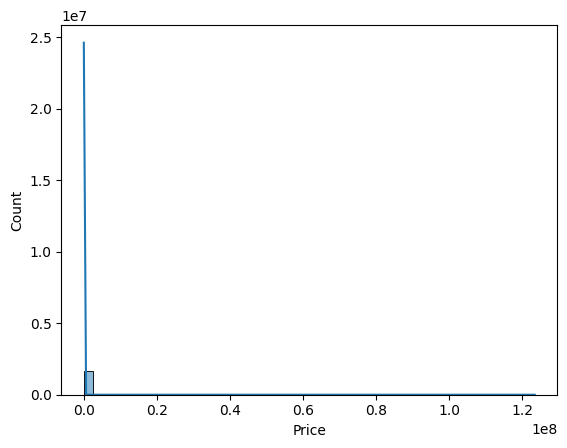

In [92]:
#Distribution of Departure Delays before handling missing values
sns.histplot(new_df['Price'], bins=50, kde=True)

In [93]:
# A function to identify outliers using IQR
def identify_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers,lower_bound,upper_bound

In [95]:
# Identify outliers in the 'Price' column
price_outliers,price_lower_bound, price_upper_bound = identify_outliers_iqr(new_df['Price'])
print(f"Total Number of Price outliers are observed to be {len(price_outliers)} \nwhere upper-bound and lower-bound values are {price_upper_bound},{price_lower_bound} and, \nmaximum and minimum Price values observed in the dataset are {max(new_df['Price'])} , {min(new_df['Price'])} respectively!!")


Total Number of Price outliers are observed to be 56213 
where upper-bound and lower-bound values are 52068.5,-9255.5 and, 
maximum and minimum Price values observed in the dataset are 123456789.0 , 1.0 respectively!!


In [96]:
# Winsorization to cap extreme values
new_df['Price'] = mstats.winsorize(new_df['Price'], limits=[0.005,0.0005])

# Identify outliers in the 'DEP_DELAY' column
dep_delay_outliers,dep_delay_lower_bound, dep_delay_upper_bound = identify_outliers_iqr(new_df['Price'])
print(f"Post Winsorization, Total Number of Price outliers are observed to be {len(dep_delay_outliers)} \nwhere upper-bound and lower-bound values are {dep_delay_upper_bound},{dep_delay_lower_bound} and, \nmaximum and minimum Price values observed in the dataset are {max(new_df['Price'])} , {min(new_df['Price'])} respectively!!")


Post Winsorization, Total Number of Price outliers are observed to be 56213 
where upper-bound and lower-bound values are 52068.5,-9255.5 and, 
maximum and minimum Price values observed in the dataset are 242995.0 , 2495.0 respectively!!


<Axes: xlabel='Price', ylabel='Count'>

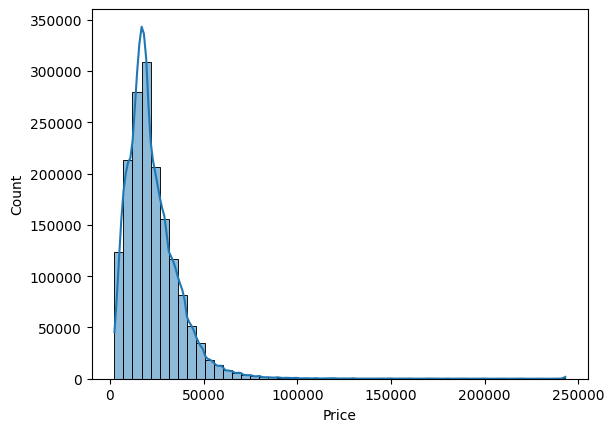

In [97]:
#Distribution of Departure Delays before handling missing values
sns.histplot(new_df['Price'], bins=50, kde=True)

In [99]:
avg_miles_by_state.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   STATE             51 non-null     object
 1   State Abbv        51 non-null     object
 2   Miles Per Driver  51 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


In [100]:
avg_miles_by_state.head()

,STATE,State Abbv,Miles Per Driver
0,Alabama,AL,19589
1,Alaska,AK,11077
2,Arizona,AZ,12728
3,Arkansas,AR,16657
4,California,CA,11464


In [101]:
new_df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer              1533353
Post Content            28095
State                    1288
dtype: int64

In [104]:
new_df['State'] = new_df['State'].str.upper()

# Merge the two dataframes on the 'state' column
merged_df = pd.merge(new_df, avg_miles_by_state, left_on='State', right_on='State Abbv', how='left')

# Convert 'manufacturing_year' column to integer type
merged_df['Manufacturing Year'] = merged_df['Manufacturing Year'].astype(int)

merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1633954 entries, 0 to 1633953
Data columns (total 17 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   Unnamed: 0          1633954 non-null  int64  
 1   Price               1633954 non-null  float64
 2   City                1633954 non-null  object 
 3   VIN                 1633953 non-null  object 
 4   Date                101293 non-null   object 
 5   Manufacturing Year  1633954 non-null  int32  
 6   Manufacturer        1631984 non-null  object 
 7   Model Name          1633493 non-null  object 
 8   cylinders           1558802 non-null  object 
 9   drive               1566031 non-null  object 
 10  transmission        1607697 non-null  object 
 11  odometer            100601 non-null   float64
 12  Post Content        1605859 non-null  object 
 13  State               1632666 non-null  object 
 14  STATE               1632648 non-null  object 
 15  State Abbv     

In [105]:
merged_df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer              1533353
Post Content            28095
State                    1288
STATE                    1306
State Abbv               1306
Miles Per Driver         1306
dtype: int64

In [106]:
merged_df['odometer'] = merged_df.apply(lambda row: ((2024 - row['Manufacturing Year']) * row['Miles Per Driver']) if pd.isna(row['odometer']) else row['odometer'], axis=1)


In [107]:
merged_df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer                 1306
Post Content            28095
State                    1288
STATE                    1306
State Abbv               1306
Miles Per Driver         1306
dtype: int64

In [109]:
# Drop redundant columns
merged_df.drop(['STATE', 'State Abbv','Miles Per Driver'], axis=1, inplace=True)


In [110]:
merged_df.to_csv('C:/My Files/KG PC Backup/Personal Projects/UCPP/Notebooks/Data/mega_df.csv')

In [3]:
import ray
ray.init()
import modin.pandas as pd

merged_df = pd.read_csv('C:/My Files/KG PC Backup/Personal Projects/UCPP/Notebooks/Data/mega_df.csv')

To remove this warning, run the following python code before doing dataframe operations:

    import ray
    ray.init()

2024-03-14 18:45:06,332	INFO worker.py:1724 -- Started a local Ray instance.


In [111]:
# Identify duplicates based on 'VIN' and 'posting_date'
model_duplicates = merged_df[merged_df.duplicated(subset=['Model Name'], keep=False)]

In [4]:
ddf = merged_df.dropna()

In [5]:
len(ddf)

52588

In [6]:
len(merged_df)

1633954

In [8]:
merged_df['Manufacturer'].unique()

array(['Chevrolet', nan, 'Honda', 'Plymouth', 'Toyota', 'Aston Martin',
       'Nissan', 'Volvo', 'Ford', 'Dodge', 'Chrysler', 'Subaru',
       'Hyundai', 'Mercedes-Benz', 'Mazda', 'HUMMER', 'AM General', 'RAM',
       'JEEP', 'Acura', 'SRT', 'GMC', 'MINI', 'harley-davidson', 'Buick',
       'Pontiac', 'Oldsmobile', 'Cadillac', 'Audi', 'Saturn', 'Isuzu',
       'Lincoln', 'Mercury', 'Volkswagen', 'Saleen', 'Mitsubishi',
       'Suzuki', 'Lexus', 'FIAT', 'Saab', 'Kia', 'BMW', 'Scion',
       'Infiniti', 'Alfa Romeo', 'Karma', 'VPG', 'Tesla',
       'Mobility Ventures', 'Ariel', 'Daewoo', 'Genesis', 'Jaguar',
       'Land Rover', 'McLaren', 'Rolls-Royce', 'Bentley', 'Lotus',
       'Bugatti', 'Porsche', 'Freightliner', 'Maybach', 'smart', 'Spyker',
       'Fisker', 'Koenigsegg', 'Lamborghini', 'Pagani', 'Maserati',
       'Ferrari'], dtype=object)

In [114]:

def most_frequent(col):
  # Filter non-null values
  filtered_col = col.dropna()
  # Return the mode (most frequent value)
  return filtered_col.mode().iloc[0] if not filtered_col.empty else None

# Group data by 'VIN' and aggregate missing values
aggregated_data = merged_df.groupby('Model Name').agg({
  'Manufacturing Year': most_frequent,  # Fill 'year' with the first non-null value
  'Manufacturer': most_frequent,        # Fill 'manufacturer' with the first non-null value
  'cylinders': most_frequent,            # Fill 'cylinders' with the most frequent value
  'drive': most_frequent,                # Fill 'drive' with the most frequent value
  'transmission': most_frequent,          # Fill 'transmission' with the most frequent value
  'State': most_frequent               # Fill 'state' with the first non-null value
})

In [115]:
# Fill missing values in the original DataFrame
merged_df.update(aggregated_data, overwrite=False)


In [116]:
merged_df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer                 1306
Post Content            28095
State                    1288
dtype: int64

In [119]:
import modin.pandas as pd

def fill_missing_by_model(df, group_col, fill_cols):
  # Group the DataFrame by the specified column
  grouped_df = df.groupby(group_col)

  # Create a dictionary to store the most frequent values for each group
  mode_dict = grouped_df[fill_cols].apply(lambda x: x.mode().iloc[0])

  # Fill missing values using the mode values
  for col in fill_cols:
    df[col].fillna(mode_dict[col], inplace=True)

  return df

# Assuming 'merged_df' is your DataFrame
filled_df = fill_missing_by_model(merged_df.copy(), 'Model Name', ['Manufacturer', 'cylinders', 'drive', 'transmission', 'State'])



In [120]:
filled_df.isna().sum()

Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer                 1306
Post Content            28095
State                    1288
dtype: int64

In [51]:
!pip install --no-cache-dir --extra-index-url https://pypi.nvidia.com cudf-cu11

Looking in indexes: https://pypi.org/simple, https://pypi.nvidia.com
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'error'


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [16 lines of output]
      Traceback (most recent call last):
        File "<string>", line 2, in <module>
        File "<pip-setuptools-caller>", line 34, in <module>
        File "C:\Users\Owner\AppData\Local\Temp\pip-install-ulgkjggj\cudf-cu11_76014a1529174183b721e050446c8b3c\setup.py", line 137, in <module>
          raise RuntimeError(open("ERROR.txt", "r").read())
      RuntimeError:
      ###########################################################################################
      The package you are trying to install is only a placeholder project on PyPI.org repository.
      This package is hosted on NVIDIA Python Package Index.
      
      This package can be installed as:
      ```
      $ pip install --no-cache-dir --extra-index-url https://pypi.nvidia.com cudf-cu11
      ```
      #######################################################################

In [ ]:
!nvidia-smi

In [ ]:
conda create --solver=libmamba -n rapids-23.12 -c rapidsai -c conda-forge -c nvidia rapids=23.12 python=3.9 cuda-version=11.2

In [49]:
%load_ext cudf.pandas

ModuleNotFoundError: No module named 'cudf'